## ЛР 3

In [1466]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
from typing import Tuple

In [1467]:
# 4 вариант
M1 = np.array([[0], 
               [0]])
M2 = np.array([[1], 
               [-1]])
M3 = np.array([[-1], 
               [-1]])

B1 = np.array([[0.2, 0.1],
               [0.1, 0.3]])

B2 = np.array([[0.3, 0.1],
               [0.1, 0.3]])

B3 = np.array([[0.3, -0.1],
               [-0.1, 0.2]])

In [1468]:
M1.reshape(1, 2)[0]

array([0, 0])

In [1469]:
def get_normal_vector(M: np.ndarray, B: np.ndarray, show_print: bool = False) -> np.ndarray:
    A = np.zeros((2, 2))
    A[0, 0] = np.sqrt(B[0, 0])
    A[1, 0] = B[0, 1] / A[0, 0]
    A[1, 1] = np.sqrt(B[1, 1] - np.power(A[1, 0], 2))

    k = 30  
    
    def approx_norm():
        U = np.random.uniform(0, 1, k)
        
        return (np.sum(U) - k/2) / np.sqrt(k/12)

    E = np.array([[approx_norm()], [approx_norm()]])
    
    X = np.dot(A, E) + M

    if show_print:
        print("M: \n", M)
        print("B: \n", B)
        print("A: \n", A)
        print("E (N(0,1)): \n", E)
        print("X (N(M,B)): \n", X)

    return X


def get_mean(X: np.ndarray, N: int) -> np.ndarray:
    return np.sum(X, axis=0) / N


def get_var(X: np.ndarray, N: int) -> np.ndarray:
    variances = []
    for row in X.transpose():
        mean = sum(row) / N
        var = sum((x - mean) ** 2 for x in row) / (N - 1)
        variances.append(var)

    return np.array(variances)


def get_cov(X: np.ndarray) -> np.ndarray:
    X1 = X.transpose()
    num_rows, num_cols = X1.shape
    
    means = np.array([sum(X1[i]) / num_cols for i in range(num_rows)])
    
    cov_matrix = np.zeros((num_rows, num_rows))
    
    for i in range(num_rows):
        for j in range(num_rows):
            cov = sum((X1[i, k] - means[i]) * (X1[j, k] - means[j]) for k in range(num_cols)) / (num_cols - 1)
            cov_matrix[i, j] = cov

    return np.array(cov_matrix)

n = 200

X1_samples1 = np.array([get_normal_vector(M1, B2).flatten() for _ in range(n)])
X2_samples1 = np.array([get_normal_vector(M2, B2).flatten() for _ in range(n)])

X1_samples2 = np.array([get_normal_vector(M1, B1).flatten() for _ in range(n)])
X2_samples2 = np.array([get_normal_vector(M2, B2).flatten() for _ in range(n)])

In [1470]:
def Bayes_Classificator(M1: np.ndarray, M2: np.ndarray, 
                        B: np.ndarray, min: float, max: float, 
                        prob1: float, prob2: float) -> Tuple[np.ndarray, np.ndarray]:
    M1 = M1.reshape(1, 2)[0]
    M2 = M2.reshape(1, 2)[0]

    x = np.linspace(min, max, 200)

    B_inv = np.linalg.inv(B)
    a = np.dot((M1 - M2).T,  B_inv)
    b = -0.5 * np.dot(np.dot((M1 + M2).T, B_inv), (M1 - M2)) + np.log(prob1 / prob2)

    y = (-a[0] * x - b) / a[1]

    return x, y


def criterion_Fisher(min_X1_X2, max_X1_X2, M0, M1, B0, B1):
    M1 = M1.reshape(1, 2)[0]
    M0 = M0.reshape(1, 2)[0]

    def get_W(M0, M1, B0, B1):
        return np.dot(np.linalg.inv(0.5 * (B0 + B1)), (M1 - M0))

    def get_STD2(W, B):
        return np.dot(np.dot(W.T, B), W)
    
    def get_Wn(M0, M1, B0, B1):
        W = get_W(M0, M1, B0, B1)
        std2_0 = get_STD2(W, B0)
        std2_1 = get_STD2(W, B1)

        coef1 = -1 / (std2_0 + std2_1) * np.transpose(M1 - M0)
        coef2 = np.linalg.inv(0.5 * (B0 + B1))
        coef3 = std2_1 * M0 + std2_0 * M1

        return W, np.dot(np.dot(coef1, coef2), coef3), std2_0, std2_1
    
    def get_m(W, M, Wn):
        return np.dot(W.T, M) + Wn
    
    W, Wn, _, _ = get_Wn(M0, M1, B0, B1)
    x = np.linspace(min_X1_X2, max_X1_X2, 200)
    y = (-W[0] * x - Wn) / W[1]

    return x, y


def criterion_Min_STD(X1, X2, min_X, max_X):
    U = np.zeros((3, 400))
    U[2, 200:] = 1
    U[2, :200] = -1
    U[:2, 200:] = np.copy(X1.T)
    U[:2, :200] = -np.copy(X2.T)

    G = np.ones(400)

    W = np.dot(np.dot(np.linalg.inv(np.dot(U, U.T)), U), G) 

    x = np.linspace(min_X, max_X, 200)
    y = (-W[0] * x - W[2]) / W[1]
    return x, y

In [1471]:
def fit_line_from_points(x: np.ndarray, y: np.ndarray, degree=1) -> tuple:
    if degree == 1:
        a, b = np.polyfit(x, y, deg=degree)
        eq = f'y = {a:.6f} * x + {b:.6f}'
        return float(a), float(b), eq
    elif degree == 2:
        a, b, c = np.polyfit(x, y, deg=degree)
        eq = f'y = {a:.6f} * x^2 + {b:.6f} * x + {c:.6f}'
        return float(a), float(b), float(c), eq
    else:
        return None


def compute_prob_errors_Bayes(dist: float, prob1: float, prob2: float) -> Tuple[float, float, float]:
    lambda1 = np.log(prob1 / prob2)

    err_I = float(1 - norm.cdf((lambda1 + 0.5 * dist) / np.sqrt(dist)))
    err_II = float(norm.cdf((lambda1 - 0.5 * dist) / np.sqrt(dist)))
    err = prob1 * err_I + prob2 * err_II

    return err_I, err_II, err


def compute_number_errors2(X1: np.ndarray, X2: np.ndarray, 
                          coef_a: float, coef_b: float) -> Tuple[float, float]:
    n = X1.shape[0]
    
    count_errors_I = 0
    for vector in X1:
        if coef_a * vector[0] + coef_b > vector[1]:
            count_errors_I += 1
    err_I = float(count_errors_I / n)

    count_errors_II = 0
    for vector in X2:
        if coef_a * vector[0] + coef_b < vector[1]:
            count_errors_II += 1
    err_II = float(count_errors_II / n)      

    return err_I, err_II


def compute_number_errors(X1: np.ndarray, X2: np.ndarray, coef_a: float, coef_b: float, coef_c: float) -> Tuple[float, float, float, int]:
    n = X1.shape[0]

    count_errors_I = 0
    for vector in X1:
        if coef_a * vector[0] ** 2 + coef_b * vector[0] + coef_c > vector[1]:
            count_errors_I += 1
    err_I = float(count_errors_I / n)

    count_errors_II = 0
    for vector in X2:
        if coef_a * vector[0] ** 2 + coef_b * vector[0] + coef_c < vector[1]:
            count_errors_II += 1
    err_II = float(count_errors_II / n)

    return err_I, err_II


def get_dist_Mahalanobis(M1: np.ndarray, M2: np.ndarray, B1: np.ndarray, B2 = None) -> np.ndarray:
    if B2 is None:
        B = B1
    else:
        B = (B1 + B2) / 2

    return np.dot(np.dot((M1 - M2).T, np.linalg.inv(B)), (M1 - M2))

### Равные кор. матрицы

In [1472]:
min_X1_X2_1 = np.min(np.concatenate((X1_samples1[:, 0], X2_samples1[:, 0])))
max_X1_X2_1 = np.max(np.concatenate((X1_samples1[:, 0], X2_samples1[:, 0])))

meanX1_1 = get_mean(X1_samples1, n)
meanX2_1 = get_mean(X2_samples1, n)
varX1_1 = get_var(X1_samples1, n)
varX2_1 = get_var(X2_samples1, n)  
covX1_1 = get_cov(X1_samples1) 
covX2_1 = get_cov(X2_samples1) 
varX1_1 = get_var(X1_samples1, n)
varX2_1 = get_var(X2_samples1, n)
covX1_X2_1 = ((n-1)*covX1_1 + (n-1)*covX2_1) / (2*n - 2)

prob1 = 0.5
prob2 = 1 - prob1

x_Fisher1, y_Fisher1 = criterion_Fisher(min_X1_X2_1, max_X1_X2_1, M1, M2, B1, B1)
x_Bayes1, y_Bayes1 = Bayes_Classificator(M1, M2, B1, min_X1_X2_1, max_X1_X2_1, prob1, prob2)
x_MinSTD1, y_MinSTD1 = criterion_Min_STD(X1_samples1, X2_samples1, min_X1_X2_1, max_X1_X2_1)

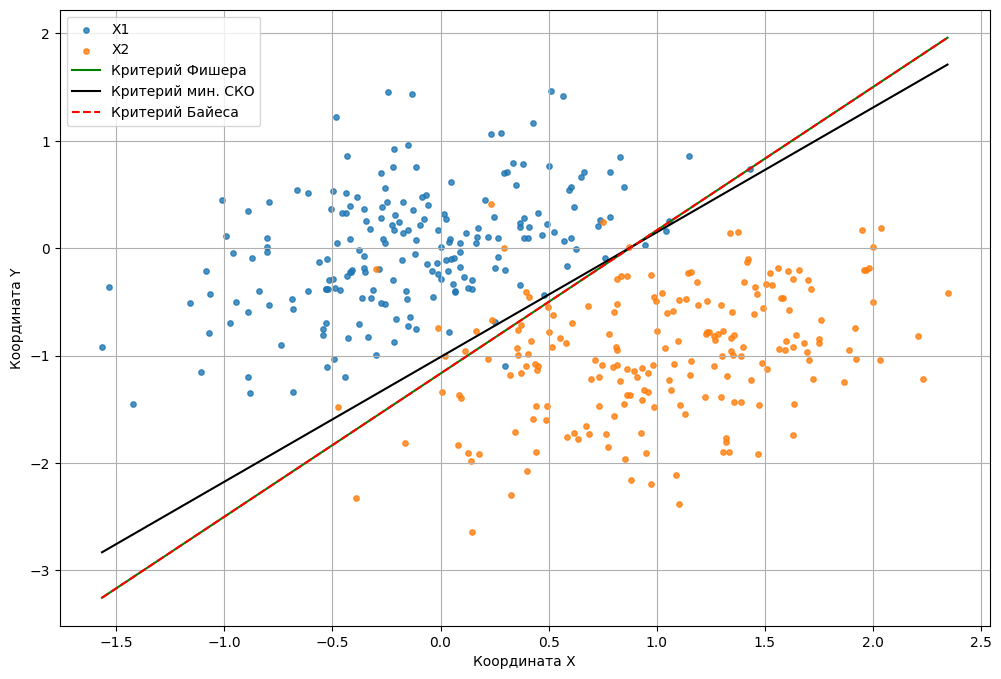

In [1473]:
plt.figure(figsize=(12,8))
plt.scatter(X1_samples1[:,0], X1_samples1[:,1], s=15, label='X1', alpha=0.8)
plt.scatter(X2_samples1[:,0], X2_samples1[:,1], s=15, label='X2', alpha=0.8)

plt.plot(x_Fisher1, y_Fisher1, label='Критерий Фишера', color='green')
plt.plot(x_MinSTD1, y_MinSTD1, label='Критерий мин. СКО', color='black')
plt.plot(x_Bayes1, y_Bayes1, label='Критерий Байесa', color='red', linestyle='--')
plt.legend()
plt.xlabel('Координата Х')
plt.ylabel('Координата Y')
plt.grid(True)

plt.show()

In [1474]:
dist_Mahalanobis = float(get_dist_Mahalanobis(meanX1_1, meanX2_1, covX1_1))
p0_Bayes1, p1_Bayes1, p_Bayes1 = compute_prob_errors_Bayes(dist_Mahalanobis, prob1, prob2)
print(f"Вероятность ошибки первого рода: {p0_Bayes1:.3f}")
print(f"Вероятность ошибки второго рода: {p1_Bayes1:.3f}")
print(f"Общий риск: {p_Bayes1:.3f}\n")

a, b, eq = fit_line_from_points(x_Bayes1, y_Bayes1)

p0_Bayes1_exp, p1_Bayes1_exp = compute_number_errors2(X1_samples1, X2_samples1, a, b)
print("Байесовкий классификатор")
print(f"Экспериментальная вероятность ошибки первого рода: {p0_Bayes1_exp:.3f}")
print(f"Экспериментальная вероятность ошибки второго рода: {p1_Bayes1_exp:.3f}\n")

a, b, eq = fit_line_from_points(x_Fisher1, y_Fisher1)

p0_Fisher1_exp, p1_Fisher1_exp = compute_number_errors2(X1_samples1, X2_samples1, a, b)
print("Классификатор Фишера")
print(f"Экспериментальная вероятность ошибки первого рода: {p0_Fisher1_exp:.3f}")
print(f"Экспериментальная вероятность ошибки второго рода: {p1_Fisher1_exp:.3f}\n")

a, b, eq = fit_line_from_points(x_MinSTD1, y_MinSTD1)

p0_MinSTD1_exp, p1_MinSTD1_exp = compute_number_errors2(X1_samples1, X2_samples1, a, b)
print("Классификатор мин. СКО")
print(f"Экспериментальная вероятность ошибки первого рода: {p0_MinSTD1_exp:.3f}")
print(f"Экспериментальная вероятность ошибки второго рода: {p1_MinSTD1_exp:.3f}\n")

Вероятность ошибки первого рода: 0.030
Вероятность ошибки второго рода: 0.030
Общий риск: 0.030

Байесовкий классификатор
Экспериментальная вероятность ошибки первого рода: 0.020
Экспериментальная вероятность ошибки второго рода: 0.065

Классификатор Фишера
Экспериментальная вероятность ошибки первого рода: 0.020
Экспериментальная вероятность ошибки второго рода: 0.065

Классификатор мин. СКО
Экспериментальная вероятность ошибки первого рода: 0.015
Экспериментальная вероятность ошибки второго рода: 0.055



### Неравные кор. матрицы

In [1475]:
def get_row_for_2_classes_for_x(M1, M2, B1, B2, x):
    A = 0.5 * (np.linalg.inv(B2) - np.linalg.inv(B1))
    
    b = np.dot(np.transpose(M1), np.linalg.inv(B1)) - np.dot(np.transpose(M2), np.linalg.inv(B2))
    c = (np.dot(np.dot(0.5 * M2.transpose(), np.linalg.inv(B2)), M2) \
         + np.dot(np.dot(-0.5 * M1.transpose(), np.linalg.inv(B1)), M1)
         + 0.5 * np.log(np.linalg.det(B2) / np.linalg.det(B1)))
    
    coeff_y = (A[1][0] * x + A[0][1] * x + b[0][1]) / A[1][1]
    coeff_c = (A[0][0] * x * x + b[0][0] * x + c[0][0]) / A[1][1]

    D = np.power(coeff_y, 2) - 4 * 1 * coeff_c

    y1 = (- coeff_y[D >= 0] + np.sqrt(D[D >= 0])) / 2
    y2 = (- coeff_y[D >= 0] - np.sqrt(D[D >= 0])) / 2

    return x[D > 0], y1, y2

In [1476]:
min_X1_X2_2 = np.min(np.concatenate((X1_samples2[:, 0], X2_samples2[:, 0])))
max_X1_X2_2 = np.max(np.concatenate((X1_samples2[:, 0], X2_samples2[:, 0])))

meanX1_2 = get_mean(X1_samples2, n)
meanX2_2 = get_mean(X2_samples2, n)
varX1_2 = get_var(X1_samples2, n)
varX2_2 = get_var(X2_samples2, n)  
covX1_2 = get_cov(X1_samples2) 
covX2_2 = get_cov(X2_samples2) 
varX1_2 = get_var(X1_samples2, n)
varX2_2 = get_var(X2_samples2, n)
covX1_X2_2 = ((n-1)*covX1_2 + (n-1)*covX2_2) / (2*n - 2)

prob1 = 0.5
prob2 = 1 - prob1

x_Fisher2, y_Fisher2 = criterion_Fisher(min_X1_X2_2, max_X1_X2_2, M1, M2, B1, B2)

meanX1_2_T = meanX1_2.reshape(-1, 1)
meanX2_2_T = meanX2_2.reshape(-1, 1)
M1_T = M1.reshape(-1, 1)
M2_T = M2.reshape(-1, 1)

x = np.linspace(min_X1_X2_2, max_X1_X2_2, 200)
x_Bayes2, y_Bayes2, _ = get_row_for_2_classes_for_x(M1_T, M2_T, covX1_2, covX2_2, x)
x_MinSTD2, y_MinSTD2 = criterion_Min_STD(X1_samples2, X2_samples2, min_X1_X2_2, max_X1_X2_2)

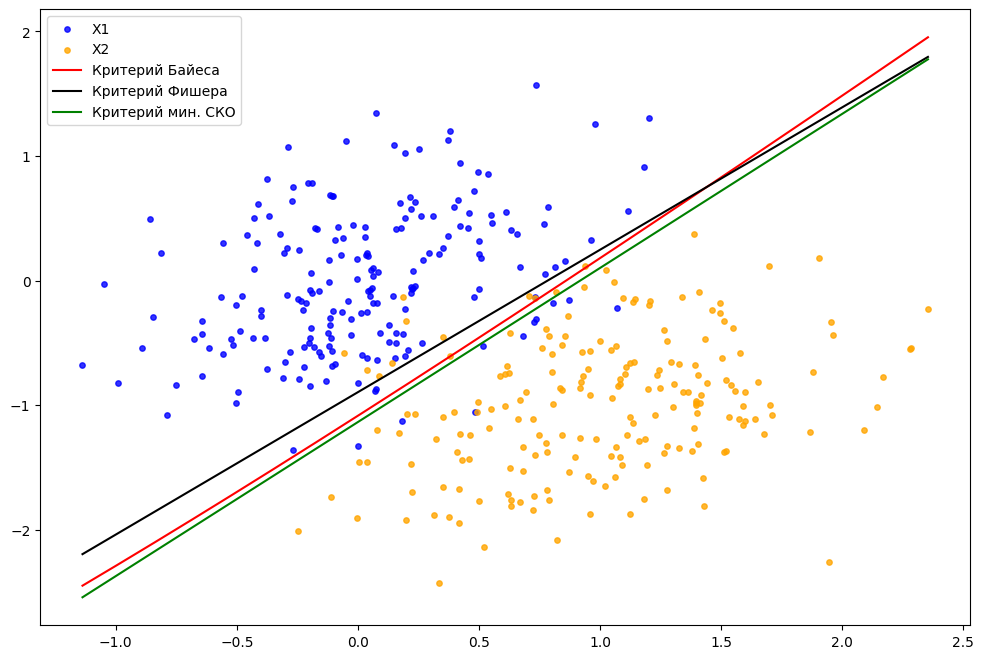

In [1477]:
plt.figure(figsize=(12, 8))

plt.scatter(X1_samples2[:,0], X1_samples2[:,1], s=15, label='X1', alpha=0.8, color="blue")
plt.scatter(X2_samples2[:,0], X2_samples2[:,1], s=15, label='X2', alpha=0.8, color="orange")

plt.plot(x_Bayes2, y_Bayes2, color='red', label='Критерий Байеса')
plt.plot(x_Fisher2, y_Fisher2, label='Критерий Фишера', color='black')
plt.plot(x_MinSTD2, y_MinSTD2, label='Критерий мин. СКО', color='green')
plt.legend(loc="upper left")

plt.show()

In [1478]:
a, b, c, eq = fit_line_from_points(x_Bayes2, y_Bayes2, degree=2)

p0_Bayes2_exp, p1_Bayes2_exp = compute_number_errors(X1_samples2, X2_samples2, a, b, c)
print("Байесовкий классификатор")
print(f"Экспериментальная вероятность ошибки первого рода: {p0_Bayes2_exp:.3f}")
print(f"Экспериментальная вероятность ошибки второго рода: {p1_Bayes2_exp:.3f}\n")

a, b, eq = fit_line_from_points(x_Fisher2, y_Fisher2)

p0_Fisher2_exp, p1_Fisher2_exp = compute_number_errors2(X1_samples2, X2_samples2, a, b)
print("Классификатор Фишера")
print(f"Экспериментальная вероятность ошибки первого рода: {p0_Fisher2_exp:.3f}")
print(f"Экспериментальная вероятность ошибки второго рода: {p1_Fisher2_exp:.3f}\n")

a, b, eq = fit_line_from_points(x_MinSTD2, y_MinSTD2)

p0_MinSTD2_exp, p1_MinSTD2_exp = compute_number_errors2(X1_samples2, X2_samples2, a, b)
print("Классификатор мин. СКО")
print(f"Экспериментальная вероятность ошибки первого рода: {p0_MinSTD2_exp:.3f}")
print(f"Экспериментальная вероятность ошибки второго рода: {p1_MinSTD2_exp:.3f}\n")

Байесовкий классификатор
Экспериментальная вероятность ошибки первого рода: 0.050
Экспериментальная вероятность ошибки второго рода: 0.055

Классификатор Фишера
Экспериментальная вероятность ошибки первого рода: 0.070
Экспериментальная вероятность ошибки второго рода: 0.035

Классификатор мин. СКО
Экспериментальная вероятность ошибки первого рода: 0.050
Экспериментальная вероятность ошибки второго рода: 0.060



### Классификатор Роббинса-Монро

In [1479]:
def cos_similarity(x: np.ndarray, y: np.ndarray) -> float:
    dot_product = np.dot(x, y)
    norm_x = np.linalg.norm(x)
    norm_y = np.linalg.norm(y)
    
    if norm_x == 0 or norm_y == 0:
        return 0.0
    
    return float(dot_product / (norm_x * norm_y))


def Robinson_Monroe(X1, X2, min_X, max_X, beta, W, epsilon=1e-5, plot=False):
    X = np.zeros((4, 400))
    X[2, :400] = 1
    X[3, 200:] = 1
    X[3, :200] = -1
    X[:2, :200] = X1.T
    X[:2, 200:] = X2.T

    X = np.transpose(X)
    np.random.shuffle(X)
    X = np.transpose(X)
    prev = W

    if plot:
        plt.figure(figsize=(12, 8))
        plt.scatter(X1[:,0], X1[:,1], s=15, label='X1', alpha=0.8, color="blue")
        plt.scatter(X2[:,0], X2[:,1], s=15, label='X2', alpha=0.8, color="orange")

    Wepoch = W
    counter = 1
    epoch = 1
    while True:
        if epoch != 1:
            Wepoch = Wi
        for i in range(1, 401):
            alpha = 1 / (counter ** beta)
            Wi = prev + alpha * X[:3, i - 1] * np.sign(X[3][i - 1] - np.dot(prev, X[:3, i - 1]))
            prev = Wi
            counter += 1

        if plot:
            print(f"Epoch {epoch}")
            x0 = np.linspace(min_X, max_X, 100)
            x1 = (-Wi[0] * x0 - Wi[2]) / Wi[1]
            if i % 200 == 0 or i==1:
                # print(f'alpha({i}) = {alpha}')
                plt.plot(x0, x1, label=f"epoch {epoch}")

            print(f"Cos dist: {np.abs(cos_similarity(Wepoch[:2], Wi[:2]))}")
            print(f"alpha: {alpha}")
            print(f"W{epoch-1}: {Wepoch} W{epoch}: {Wi}\n")

        if cos_similarity(Wepoch[:2], Wi[:2]) > 1 - epsilon: 
            if plot: print(f"Converged at epoch {epoch}")
            break
        
        epoch += 1

    if plot:
        plt.legend()

    x = np.linspace(min_X, max_X, 200)
    y = (-Wi[0] * x - Wi[2]) / Wi[1]

    return x, y, epoch

#### Равные кор. матрицы

Epoch 1
Cos dist: 0.035317099774711494
alpha: 0.04177420605417951
W0: [5, 5, 5] W1: [ 0.77156741 -0.82809822 -0.60812702]

Epoch 2
Cos dist: 0.9999853730851028
alpha: 0.028930924164230376
W1: [ 0.77156741 -0.82809822 -0.60812702] W2: [ 0.75352074 -0.81755082 -0.57565909]

Epoch 3
Cos dist: 0.9998893559161053
alpha: 0.023336404263656543
W2: [ 0.75352074 -0.81755082 -0.57565909] W3: [ 0.7520839  -0.79201904 -0.59775122]

Epoch 4
Cos dist: 0.9999669992640671
alpha: 0.02003624849053732
W3: [ 0.7520839  -0.79201904 -0.59775122] W4: [ 0.77338362 -0.82781554 -0.56957249]

Epoch 5
Cos dist: 0.9999293520136548
alpha: 0.01780139767752772
W4: [ 0.77338362 -0.82781554 -0.56957249] W5: [ 0.76465492 -0.79921347 -0.58283376]

Epoch 6
Cos dist: 0.9996844076147
alpha: 0.016161737248627416
W5: [ 0.76465492 -0.79921347 -0.58283376] W6: [ 0.75872538 -0.75414209 -0.62480284]

Epoch 7
Cos dist: 0.9995463936211412
alpha: 0.014893824888207391
W6: [ 0.75872538 -0.75414209 -0.62480284] W7: [ 0.74762501 -0.78927

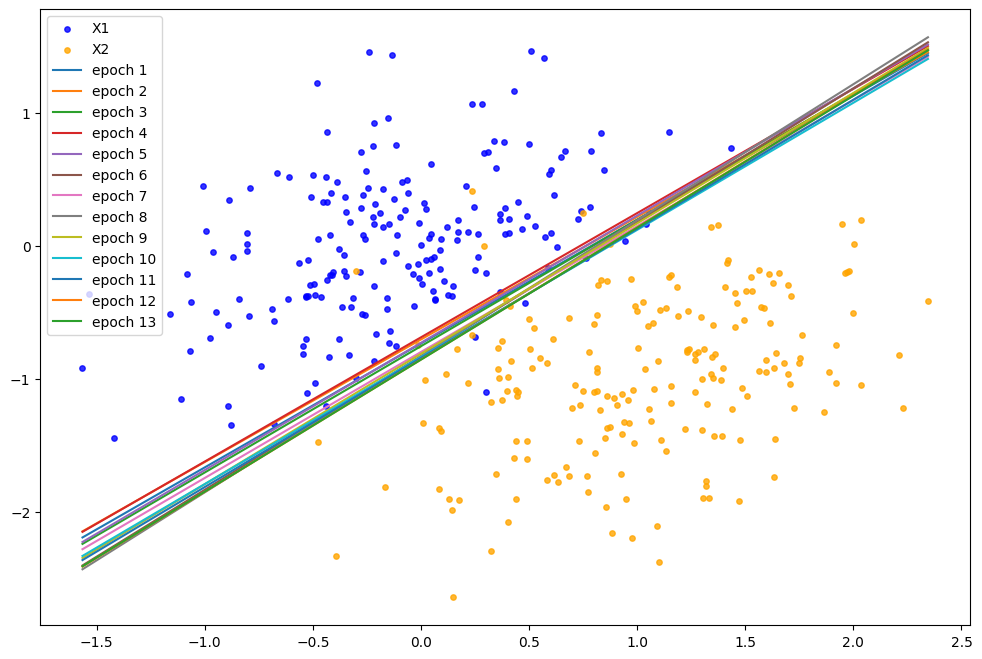

In [1480]:
x_RM1, y_RM1, epoch = Robinson_Monroe(X1_samples1, X2_samples1, min_X1_X2_1, max_X1_X2_1, beta=0.53, W=[5, 5, 5], plot=True)

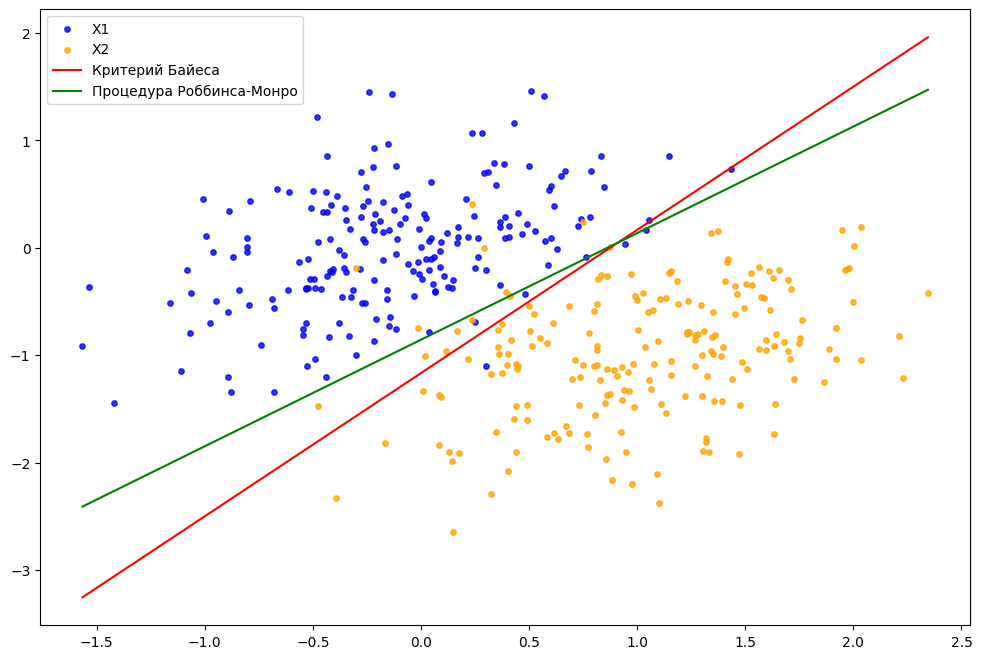

In [1481]:
plt.figure(figsize=(12, 8))

plt.scatter(X1_samples1[:,0], X1_samples1[:,1], s=15, label='X1', alpha=0.8, color="blue")
plt.scatter(X2_samples1[:,0], X2_samples1[:,1], s=15, label='X2', alpha=0.8, color="orange")

plt.plot(x_Bayes1, y_Bayes1, label='Критерий Байеса', color='red')
plt.plot(x_RM1, y_RM1, label='Процедура Роббинса-Монро', color='green')
plt.legend(loc="upper left")

plt.show()

In [1482]:
a, b, eq = fit_line_from_points(x_Bayes1, y_Bayes1)

p0_Bayes1_exp, p1_Bayes1_exp = compute_number_errors2(X1_samples1, X2_samples1, a, b)
print("Байесовкий классификатор")
print(f"Экспериментальная вероятность ошибки первого рода: {p0_Bayes1_exp:.3f}")
print(f"Экспериментальная вероятность ошибки второго рода: {p1_Bayes1_exp:.3f}\n")

a, b, eq = fit_line_from_points(x_RM1, y_RM1)

p0_RM1_exp, p1_RM1_exp = compute_number_errors2(X1_samples1, X2_samples1, a, b)
print("Процедура Роббинса-Монро")
print(f"Экспериментальная вероятность ошибки первого рода: {p0_RM1_exp:.3f}")
print(f"Экспериментальная вероятность ошибки второго рода: {p1_RM1_exp:.3f}\n")

Байесовкий классификатор
Экспериментальная вероятность ошибки первого рода: 0.020
Экспериментальная вероятность ошибки второго рода: 0.065

Процедура Роббинса-Монро
Экспериментальная вероятность ошибки первого рода: 0.025
Экспериментальная вероятность ошибки второго рода: 0.035



#### Неравные кор. матрицы

Epoch 1
Cos dist: 0.44365169003236726
alpha: 0.04177420605417951
W0: [10, 10, 10] W1: [ 0.75581623 -0.25528423 -0.70938936]

Epoch 2
Cos dist: 0.9597057368545968
alpha: 0.028930924164230376
W1: [ 0.75581623 -0.25528423 -0.70938936] W2: [ 0.6907156  -0.48334259 -0.92292741]

Epoch 3
Cos dist: 0.9997820323397083
alpha: 0.023336404263656543
W2: [ 0.6907156  -0.48334259 -0.92292741] W3: [ 0.75254641 -0.50353679 -0.87899094]

Epoch 4
Cos dist: 0.9999301956823198
alpha: 0.02003624849053732
W3: [ 0.75254641 -0.50353679 -0.87899094] W4: [ 0.77821581 -0.50750437 -0.85337713]

Epoch 5
Cos dist: 0.9993057371858886
alpha: 0.01780139767752772
W4: [ 0.77821581 -0.50750437 -0.85337713] W5: [ 0.76461772 -0.54027921 -0.8368089 ]

Epoch 6
Cos dist: 0.9994273232417421
alpha: 0.016161737248627416
W5: [ 0.76461772 -0.54027921 -0.8368089 ] W6: [ 0.73849492 -0.56022727 -0.79124828]

Epoch 7
Cos dist: 0.9994790586248863
alpha: 0.014893824888207391
W6: [ 0.73849492 -0.56022727 -0.79124828] W7: [ 0.74454718 -0.

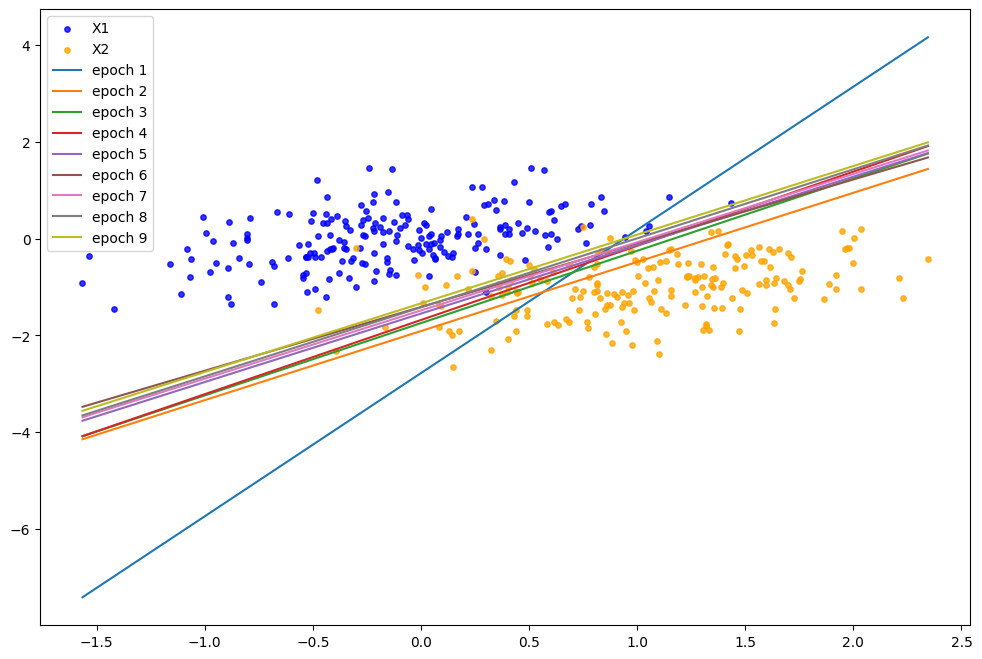

In [1483]:
x_RM1, y_RM1, epoch = Robinson_Monroe(X1_samples1, X2_samples1, min_X1_X2_1, max_X1_X2_1, beta=0.53, W=[10, 10, 10], plot=True)

In [1484]:
x_RM2, y_RM2, epoch = Robinson_Monroe(X1_samples2, X2_samples2, min_X1_X2_2, max_X1_X2_2, beta=0.99, W=[1,1,1])

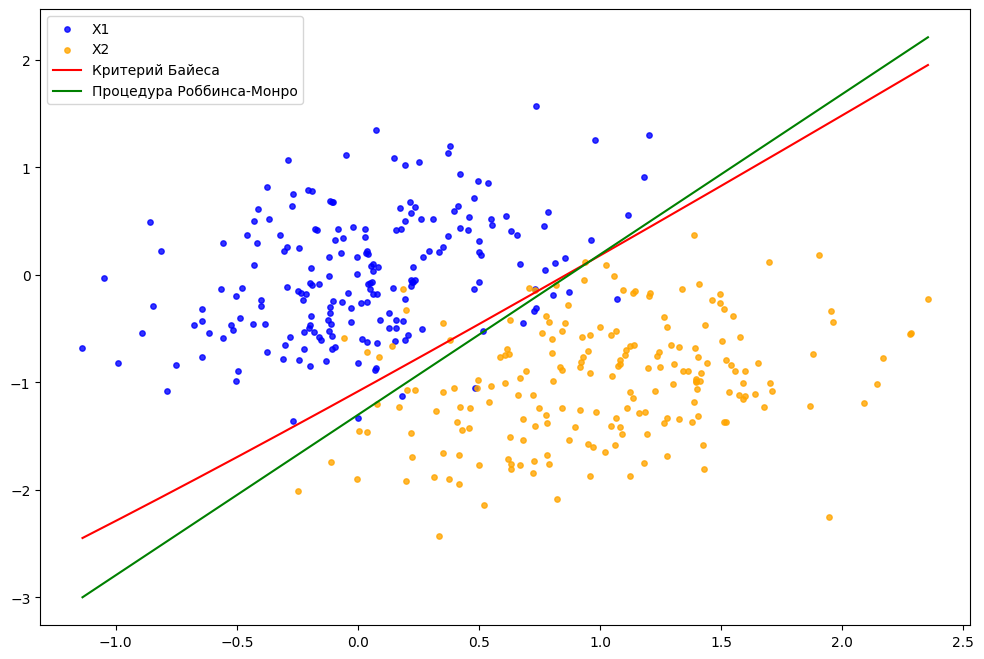

In [1485]:
plt.figure(figsize=(12, 8))

plt.scatter(X1_samples2[:,0], X1_samples2[:,1], s=15, label='X1', alpha=0.8, color="blue")
plt.scatter(X2_samples2[:,0], X2_samples2[:,1], s=15, label='X2', alpha=0.8, color="orange")

plt.plot(x_Bayes2, y_Bayes2, label='Критерий Байеса', color='red')
plt.plot(x_RM2, y_RM2, label='Процедура Роббинса-Монро', color='green')
plt.legend(loc="upper left")

plt.show()

In [1486]:
a, b, c, eq = fit_line_from_points(x_Bayes2, y_Bayes2, degree=2)

p0_Bayes2_exp, p1_Bayes2_exp = compute_number_errors(X1_samples2, X2_samples2, a, b, c)
print("Байесовкий классификатор")
print(f"Экспериментальная вероятность ошибки первого рода: {p0_Bayes2_exp:.3f}")
print(f"Экспериментальная вероятность ошибки второго рода: {p1_Bayes2_exp:.3f}\n")

a, b, eq = fit_line_from_points(x_RM2, y_RM2)

p0_RM2_exp, p1_RM2_exp = compute_number_errors2(X1_samples2, X2_samples2, a, b)
print("Процедура Роббинса-Монро")
print(f"Экспериментальная вероятность ошибки первого рода: {p0_RM2_exp:.3f}")
print(f"Экспериментальная вероятность ошибки второго рода: {p1_RM2_exp:.3f}\n")

Байесовкий классификатор
Экспериментальная вероятность ошибки первого рода: 0.050
Экспериментальная вероятность ошибки второго рода: 0.055

Процедура Роббинса-Монро
Экспериментальная вероятность ошибки первого рода: 0.045
Экспериментальная вероятность ошибки второго рода: 0.055



0.5 1.0


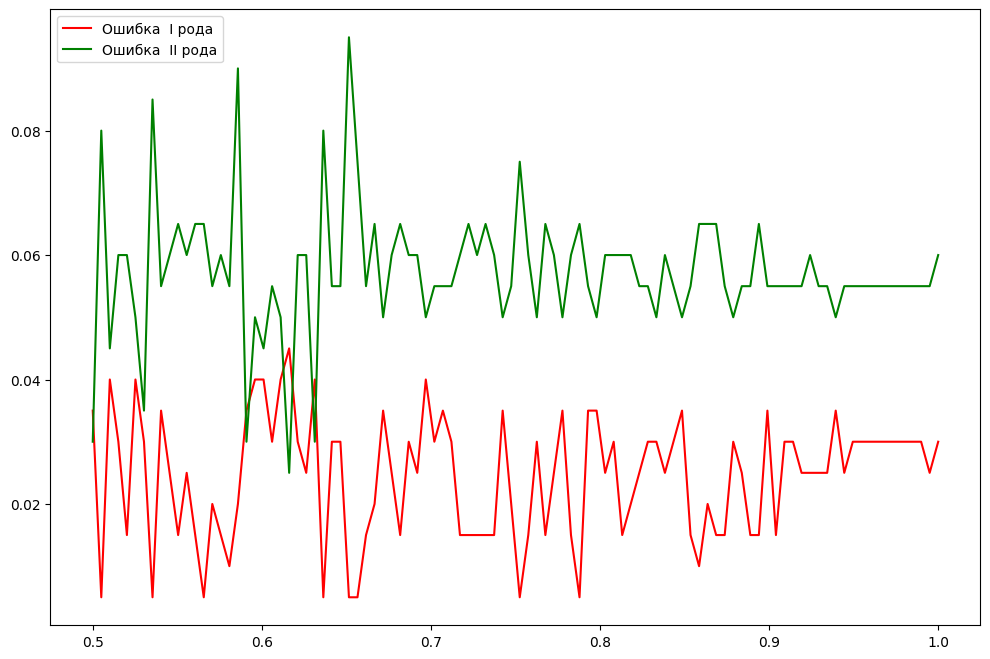

In [1487]:
errors0 = []
errors1 = []
epochs = []
betas = np.linspace(0.5, 1.0, 100)
print(betas[0], betas[-1])


for beta in betas:
    xi, yi, epoch = Robinson_Monroe(X1_samples1, X2_samples1, min_X1_X2_1, max_X1_X2_1, beta=beta, W=[1, 1, 1])

    a, b, eq = fit_line_from_points(xi, yi)
    p0, p1 = compute_number_errors2(X1_samples1, X2_samples1, a, b)

    epochs.append(epoch)
    errors0.append(p0)
    errors1.append(p1)

plt.figure(figsize=(12, 8))

plt.plot(betas, errors0, label='Ошибка  I рода', color='red')
plt.plot(betas, errors1, label='Ошибка  II рода', color='green')
plt.legend(loc="upper left")

plt.show()

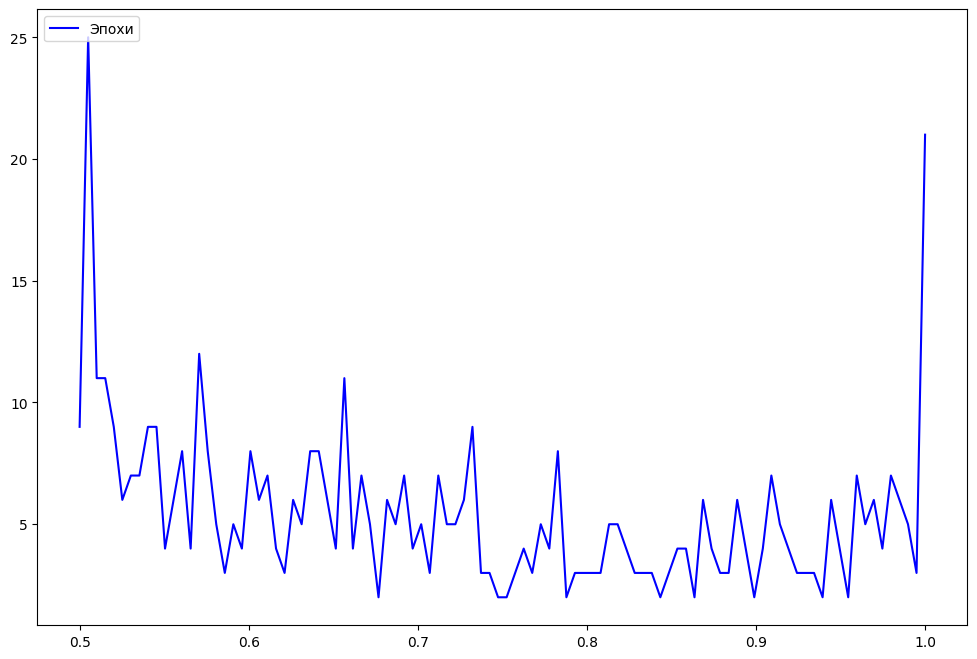

In [1488]:
plt.figure(figsize=(12, 8))

plt.plot(betas, epochs, label='Эпохи', color='blue')
plt.legend(loc="upper left")

plt.show()

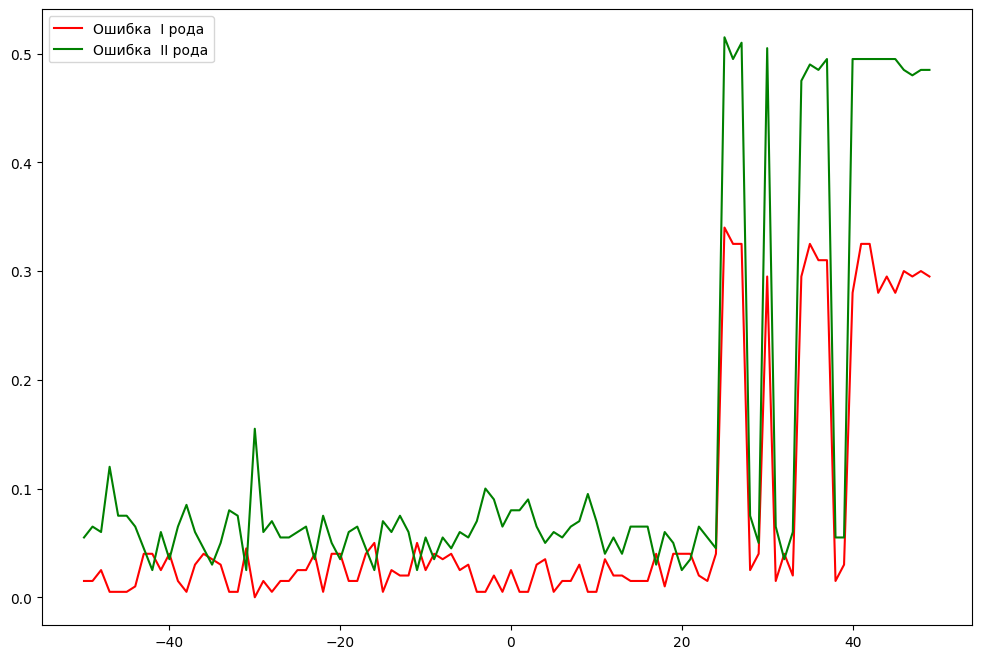

In [1489]:
errors0 = []
errors1 = []
epochs = []
Ws = [[i, i, i] for i in range(-50, 50, 1)]

for wi in Ws:
    xi, yi, epoch = Robinson_Monroe(X1_samples1, X2_samples1, min_X1_X2_1, max_X1_X2_1, beta=0.51, W=wi)

    a, b, eq = fit_line_from_points(xi, yi)
    p0, p1 = compute_number_errors2(X1_samples1, X2_samples1, a, b)

    epochs.append(epoch)
    errors0.append(p0)
    errors1.append(p1)

plt.figure(figsize=(12, 8))

plt.plot(range(-50, 50, 1), errors0, label='Ошибка  I рода', color='red')
plt.plot(range(-50, 50, 1), errors1, label='Ошибка  II рода', color='green')
plt.legend(loc="upper left")

plt.show()

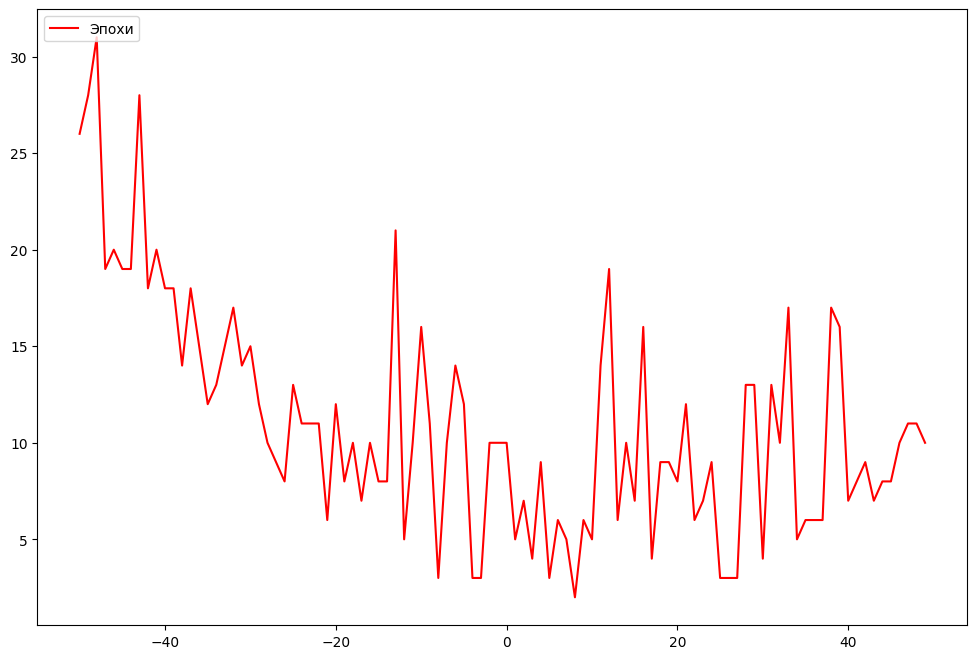

In [1490]:
plt.figure(figsize=(12, 8))

plt.plot(range(-50, 50, 1), epochs, label='Эпохи', color='red')
plt.legend(loc="upper left")

plt.show()